In [3]:
import torch
import torch.nn as nn
import matplotlib.pyplot as plt

In [3]:

# ============================================================
# 1. Generate step-function dataset
# ============================================================
torch.manual_seed(0)

N = 100
x = torch.linspace(-2, 2, N).reshape(-1, 1)

# Step function: y = 0 if x < 0, y = 1 if x >= 0
y = (x >= 0).float()

# Smooth grid for plotting
x_plot = torch.linspace(-2.5, 2.5, 100).reshape(-1, 1)
y_true_plot = (x_plot >= 0).float()

In [4]:



# ============================================================
# 2. Linear regression model
# ============================================================
linear_model = nn.Linear(1, 1)

linear_optimizer = torch.optim.Adam(linear_model.parameters(), lr=0.05)
mse_loss = nn.MSELoss()

linear_loss_history = []

for step in range(1000):
    y_pred = linear_model(x)
    loss = mse_loss(y_pred, y)

    linear_optimizer.zero_grad()
    loss.backward()
    linear_optimizer.step()

    linear_loss_history.append(loss.item())


# ============================================================
# 3. Three-layer MLP model
# ============================================================
class ThreeLayerMLP(nn.Module):
    def __init__(self, hidden_dim=64):
        super().__init__()

        self.net = nn.Sequential(
            nn.Linear(1, hidden_dim),
            nn.Tanh(),
            nn.Linear(hidden_dim, hidden_dim),
            nn.Tanh(),
            nn.Linear(hidden_dim, 1)
        )

    def forward(self, x):
        return self.net(x)


mlp_model = ThreeLayerMLP(hidden_dim=64)

mlp_optimizer = torch.optim.Adam(mlp_model.parameters(), lr=0.01)
bce_loss = nn.BCEWithLogitsLoss()

mlp_loss_history = []

for step in range(1000):
    logits = mlp_model(x)
    loss = bce_loss(logits, y)

    mlp_optimizer.zero_grad()
    loss.backward()
    mlp_optimizer.step()

    mlp_loss_history.append(loss.item())


# ============================================================
# 4. Prediction for visualization
# ============================================================
with torch.no_grad():
    y_linear_plot = linear_model(x_plot)

    mlp_logits_plot = mlp_model(x_plot)
    y_mlp_plot = torch.sigmoid(mlp_logits_plot)


In [5]:
# ============================================================
# 5. Visualization: 1 x 3 subplots
# ============================================================
fig, axes = plt.subplots(1, 3, figsize=(14, 3))



# ------------------------------------------------------------
# 1) Linear regression fails
# ------------------------------------------------------------
ax = axes[0]

ax.scatter(
    x.numpy(),
    y.numpy(),
    color="black",
    alpha=0.5,
    label="Dataset",
    facecolors="none",   # empty inside       
)

ax.plot(
    x_plot.numpy(),
    y_true_plot.numpy(),
    color="red",
    linewidth=3,
    label="True step fun"
)

ax.plot(
    x_plot.numpy(),
    y_linear_plot.numpy(),
    color="blue",
    linewidth=3,
    label="Linear regression"
)

ax.set_title("Linear Case")
ax.set_xlabel("x")
ax.set_ylabel("y")
ax.set_ylim(-0.2, 1.2)
ax.grid(True, alpha=0.3)
ax.legend(fontsize=10)



# ------------------------------------------------------------
# 2) MLP succeeds
# ------------------------------------------------------------
ax = axes[1]

ax.scatter(
    x.numpy(),
    y.numpy(),
    color="black",
    alpha=0.5,
    label="Dataset",
    facecolors="none",   # empty inside    
)

ax.plot(
    x_plot.numpy(),
    y_true_plot.numpy(),
    color="red",
    linewidth=3,
    label="True step fun"
)

ax.plot(
    x_plot.numpy(),
    y_mlp_plot.numpy(),
    color="blue",
    linewidth=3,
    label="3-layer MLP"
)

ax.set_title("MLP Case")
ax.set_xlabel("x")
ax.set_ylabel("y")
ax.set_ylim(-0.2, 1.2)
ax.grid(True, alpha=0.3)
ax.legend(fontsize=10)


# ------------------------------------------------------------
# 3) Training loss
# ------------------------------------------------------------
ax = axes[2]

ax.plot(
    linear_loss_history,
    color="blue",
    alpha=0.7,
    linewidth=2,
    label="Linear regression"
)

ax.plot(
    mlp_loss_history,
    color="red",
    alpha=0.7,
    linewidth=2,
    label="3-layer MLP"
)

ax.set_title("Training Loss")
ax.set_xlabel("Training step")
ax.set_ylabel("Loss")
ax.grid(True, alpha=0.3)
ax.legend(fontsize=10)


# ------------------------------------------------------------
# Save and show
# ------------------------------------------------------------
plt.tight_layout(w_pad=1)
fig.savefig("reg2-results.png", dpi=300, bbox_inches="tight")
plt.show()

NameError: name 'plt' is not defined

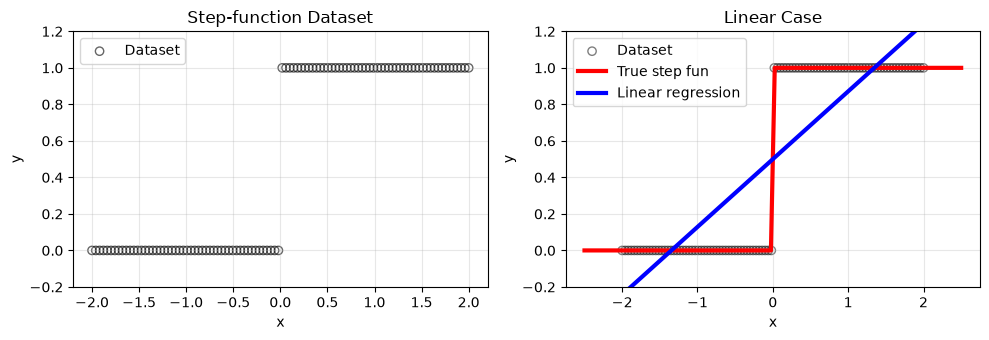

In [ ]:
# ============================================================
# 5. Visualization: dataset only
# ============================================================
fig, axes = plt.subplots(1,2,  figsize=(10, 3.5))

ax = axes[0]

ax.scatter(
    x.numpy(),
    y.numpy(),
    facecolors="none",   # empty inside    
    color="black",
    alpha=0.6,
    label="Dataset",
)


ax.set_title("Step-function Dataset")
ax.set_xlabel("x")
ax.set_ylabel("y")
ax.set_ylim(-0.2, 1.2)
ax.grid(True,alpha=0.3)
ax.legend(fontsize=10, loc="upper left")




# ------------------------------------------------------------
# 1) Linear regression fails
# ------------------------------------------------------------
ax = axes[1]

ax.scatter(
    x.numpy(),
    y.numpy(),
    color="black",
    alpha=0.5,
    label="Dataset",
    facecolors="none",   # empty inside       
)

ax.plot(
    x_plot.numpy(),
    y_true_plot.numpy(),
    color="red",
    linewidth=3,
    label="True step fun"
)

ax.plot(
    x_plot.numpy(),
    y_linear_plot.numpy(),
    color="blue",
    linewidth=3,
    label="Linear regression"
)

ax.set_title("Linear Case")
ax.set_xlabel("x")
ax.set_ylabel("y")
ax.set_ylim(-0.2, 1.2)
ax.grid(True, alpha=0.3)
ax.legend(fontsize=10)



plt.tight_layout()
fig.savefig("reg2-dataset.png", dpi=300, bbox_inches="tight")
plt.show()

In [6]:
# ============================================================
# 2.5 Linear model with nonlinear features: phi(x) = [x, x^3]
# ============================================================

import torch
import torch.nn as nn

def cubic_feature(x):
    return torch.cat([x, x**3], dim=1)


feature_model = nn.Linear(2, 1)

feature_optimizer = torch.optim.Adam(feature_model.parameters(), lr=0.05)
bce_loss = nn.BCEWithLogitsLoss()

feature_loss_history = []

x_feature = cubic_feature(x)

for step in range(1000):
    logits = feature_model(x_feature)
    loss = bce_loss(logits, y)

    feature_optimizer.zero_grad()
    loss.backward()
    feature_optimizer.step()

    feature_loss_history.append(loss.item())


# ============================================================
# Prediction for visualization
# ============================================================
with torch.no_grad():
    x_plot_feature = cubic_feature(x_plot)

    feature_logits_plot = feature_model(x_plot_feature)
    y_feature_plot = torch.sigmoid(feature_logits_plot)

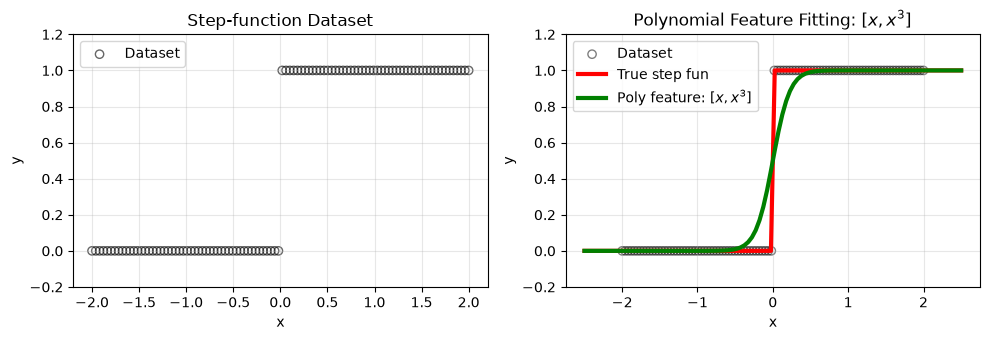

In [9]:
# ============================================================
# 5. Visualization: dataset + polynomial feature fitting
# ============================================================
fig, axes = plt.subplots(1, 2, figsize=(10, 3.5))

# ------------------------------------------------------------
# 0) Dataset only
# ------------------------------------------------------------
ax = axes[0]

ax.scatter(
    x.numpy(),
    y.numpy(),
    facecolors="none",
    edgecolors="black",
    alpha=0.6,
    label="Dataset",
)

ax.set_title("Step-function Dataset")
ax.set_xlabel("x")
ax.set_ylabel("y")
ax.set_ylim(-0.2, 1.2)
ax.grid(True, alpha=0.3)
ax.legend(fontsize=10, loc="upper left")


# ------------------------------------------------------------
# 1) Polynomial feature fitting
# ------------------------------------------------------------
ax = axes[1]

ax.scatter(
    x.numpy(),
    y.numpy(),
    facecolors="none",
    edgecolors="black",
    alpha=0.5,
    label="Dataset",
)

ax.plot(
    x_plot.numpy(),
    y_true_plot.numpy(),
    color="red",
    linewidth=3,
    label="True step fun",
)

ax.plot(
    x_plot.numpy(),
    y_feature_plot.numpy(),
    color="green",
    linewidth=3,
    label=r"Poly feature: $[x, x^3]$",
)

ax.set_title(r"Polynomial Feature Fitting: $[x, x^3]$")
ax.set_xlabel("x")
ax.set_ylabel("y")
ax.set_ylim(-0.2, 1.2)
ax.grid(True, alpha=0.3)
ax.legend(fontsize=10)


plt.tight_layout()
fig.savefig("reg2-poly-feature.png", dpi=300, bbox_inches="tight")
plt.show()